# Step 1: Define the Problem and Load the Dataset

## Description

The objective of this project is to estimate a person's age group from a facial image using deep learning techniques.

The project uses the UTKFace dataset, which contains facial images annotated with:

- Age
- Gender
- Race

Instead of predicting an exact age, this project formulates the task as a **multi-class age-group classification problem**, which is generally more stable and easier to learn.

The selected age groups are:

| Class | Age Range |
| --- | --- |
| Young | 0–25 |
| Adult | 26–50 |
| Old | 51+ |

This approach reduces prediction complexity and helps improve classification performance.

### Code: Import Required Libraries

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random


from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# To Copy images to its own folder (validation, train, test)
import shutil
from tqdm import tqdm

print("Libraries imported successfully.")

2026-06-04 19:59:57.413238: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780603197.616043      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780603197.672614      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780603198.152809      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780603198.152849      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780603198.152852      58 computation_placer.cc:177] computation placer alr

Libraries imported successfully.


## Project Directory Setup

Create folders for figures, metadata, models, logs, and evaluation outputs.

In [4]:
# Project folders
BASE_WORK_DIR = "/kaggle/working"
PROJECT_FIGURES = f"{BASE_WORK_DIR}/project_figures"
PROJECT_DATA = f"{BASE_WORK_DIR}/project_data"
SAVED_MODELS = f"{BASE_WORK_DIR}/saved_models"
EVALUATION_RESULTS = f"{BASE_WORK_DIR}/evaluation_results"
LOGS_DIR = f"{BASE_WORK_DIR}/logs"
for folder in [PROJECT_FIGURES,PROJECT_DATA,SAVED_MODELS,EVALUATION_RESULTS,LOGS_DIR]:
    os.makedirs(folder, exist_ok=True)
print("Project folders created successfully.")


Project folders created successfully.


### Code: Define Dataset Path

In [5]:
dataset_path = "/kaggle/input/datasets/jangedoo/utkface-new/UTKFace"

print("Dataset Path:")
print(dataset_path)

Dataset Path:
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace


### Code: Count Total Images

In [6]:
image_files = os.listdir(dataset_path)

print("Total Images:", len(image_files))

Total Images: 23708


# Step 2: Explore and Analyze the Dataset

## Description

Before preprocessing and model development, it is important to understand the dataset characteristics.

This step:

- Extracts ages from filenames.
- Computes descriptive statistics.
- Visualizes the age distribution.
- Evaluates the proposed age-group categories.

Understanding the data distribution helps ensure that the selected classes are meaningful and suitable for training.

### Code: Extract Ages from Filenames

In [7]:
ages = []

for file in image_files:
    try:
        age = int(file.split('_')[0])
        ages.append(age)
    except:
        continue

print("Number of Valid Samples:", len(ages))

Number of Valid Samples: 23708


### Code: Create Age DataFrame

In [8]:
age_df = pd.DataFrame({
    "age": ages
})

age_df.head()

,age
0,26
1,22
2,21
3,28
4,17


### Code: Display Descriptive Statistics

In [9]:
age_df.describe()

,age
count,23708.000000
mean,33.303484
std,19.886112
min,1.000000
25%,23.000000
50%,29.000000
75%,45.000000
max,116.000000


### Code: Visualize Age Distribution

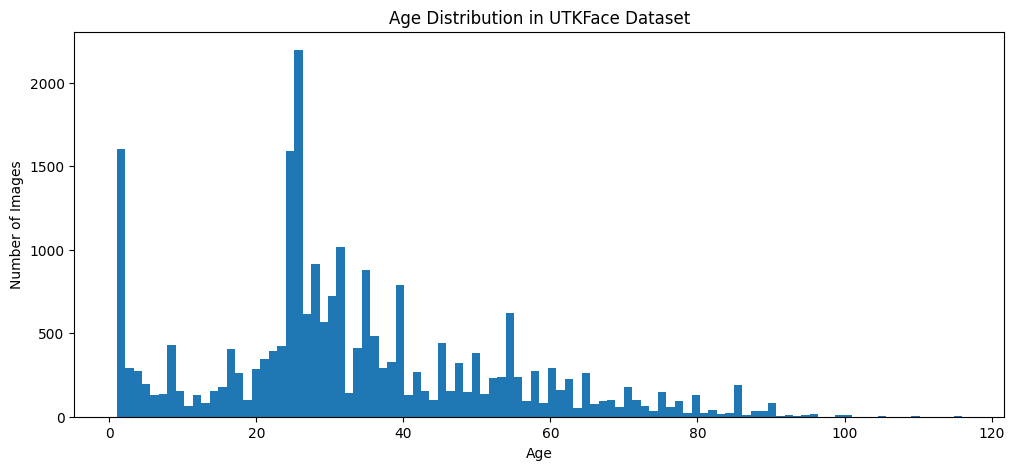

<Figure size 640x480 with 0 Axes>

In [10]:
plt.figure(figsize=(12,5))

plt.hist(
    age_df["age"],
    bins=100
)

plt.title("Age Distribution in UTKFace Dataset")
plt.xlabel("Age")
plt.ylabel("Number of Images")

plt.show()
plt.savefig(f"{PROJECT_FIGURES}/age_distribution.pdf", bbox_inches="tight")

### Code: Define Age Groups

In [11]:
def age_to_class(age):

    if age <= 25:
        return "young"

    elif age <= 50:
        return "adult"

    else:
        return "old"

### Code: Create Age-Group Labels

In [12]:
age_df["class"] = age_df["age"].apply(age_to_class)

age_df.head()

,age,class
0,26,adult
1,22,young
2,21,young
3,28,adult
4,17,young


### Code: Examine Class Distribution

Expected output:

```
adult    11463
young     7637
old       4608
```

In [13]:
class_counts = age_df["class"].value_counts()

print(class_counts)

class
adult    11463
young     7637
old       4608
Name: count, dtype: int64


### Code: Calculate Class Percentages

In [14]:
class_percentages = (
    age_df["class"]
    .value_counts(normalize=True)
    * 100
)

print(class_percentages.round(2))

class
adult    48.35
young    32.21
old      19.44
Name: proportion, dtype: float64


# Step 3: Create the Metadata Table

## Description

In this step, we create a metadata table that contains:

- Image filename
- Age extracted from the filename
- Corresponding age-group label

This table will be used throughout the project and allows us to split the dataset without loading images into memory.

### Code

In [15]:
# Age grouping function
def age_to_class(age):
    if age <= 25:
        return "young"
    elif age <= 50:
        return "adult"
    else:
        return "old"

records = []

for file in os.listdir(dataset_path):
    try:
        age = int(file.split('_')[0])

        records.append({
            "filename": file,
            "age": age,
            "class": age_to_class(age)
        })

    except:
        continue

df = pd.DataFrame(records)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (23708, 3)


,filename,age,class
0,26_0_2_20170104023102422.jpg.chip.jpg,26,adult
1,22_1_1_20170112233644761.jpg.chip.jpg,22,young
2,21_1_3_20170105003215901.jpg.chip.jpg,21,young
3,28_0_0_20170117180555824.jpg.chip.jpg,28,adult
4,17_1_4_20170103222931966.jpg.chip.jpg,17,young


In [16]:
# Save metadata table
df.to_csv(f"{PROJECT_DATA}/metadata.csv", index=False)
print("Metadata saved.")

Metadata saved.


# Step 4: Verify Age Group Distribution

## Description

Before splitting the dataset, verify that the age groups were created correctly and inspect the class distribution.

### Code

class
adult    11463
young     7637
old       4608
Name: count, dtype: int64


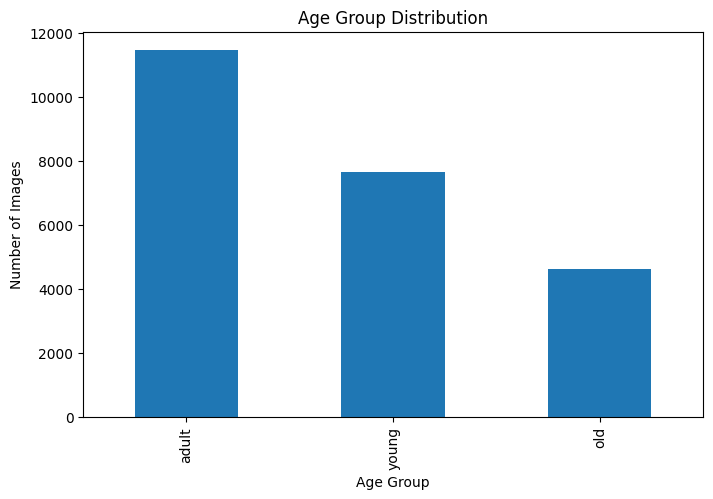

<Figure size 640x480 with 0 Axes>

In [17]:
import matplotlib.pyplot as plt

class_counts = df["class"].value_counts()

print(class_counts)

plt.figure(figsize=(8,5))
class_counts.plot(kind="bar")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Images")
plt.show()
plt.savefig(f"{PROJECT_FIGURES}/class_distribution.pdf", bbox_inches="tight")

# Step 5: Perform Stratified Train-Validation-Test Split

## Description

A stratified split preserves the proportion of each age group across all subsets.

Split ratios:

- Training: 70%
- Validation: 15%
- Testing: 15%

### Code

In [18]:
# Train = 70%, Temp = 30%
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"],
    random_state=42
)

# Validation = 15%, Test = 15%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (16595, 3)
Validation Shape: (3556, 3)
Test Shape: (3557, 3)


In [19]:
# Save dataset splits
train_df.to_csv(f"{PROJECT_DATA}/train_df.csv", index=False)
val_df.to_csv(f"{PROJECT_DATA}/val_df.csv", index=False)
test_df.to_csv(f"{PROJECT_DATA}/test_df.csv", index=False)
print("Train/Validation/Test splits saved.")

Train/Validation/Test splits saved.


# Step 6: Verify Class Distribution After Splitting

## Description

Confirm that the stratified split maintained class proportions.

### Code

In [20]:
print("Training Set")
print(train_df["class"].value_counts())

print("\nValidation Set")
print(val_df["class"].value_counts())

print("\nTest Set")
print(test_df["class"].value_counts())

Training Set
class
adult    8024
young    5346
old      3225
Name: count, dtype: int64

Validation Set
class
adult    1719
young    1145
old       692
Name: count, dtype: int64

Test Set
class
adult    1720
young    1146
old       691
Name: count, dtype: int64


### Code

In [21]:
print("Training Proportions")
print(train_df["class"].value_counts(normalize=True))

print("\nValidation Proportions")
print(val_df["class"].value_counts(normalize=True))

print("\nTest Proportions")
print(test_df["class"].value_counts(normalize=True))

Training Proportions
class
adult    0.483519
young    0.322145
old      0.194336
Name: proportion, dtype: float64

Validation Proportions
class
adult    0.483408
young    0.321991
old      0.194601
Name: proportion, dtype: float64

Test Proportions
class
adult    0.483554
young    0.322182
old      0.194265
Name: proportion, dtype: float64


# Step 7: Create Processed Dataset Folder Structure

## Description

Create the directory structure required for generator-based training.

Final structure:

```
UTKFace_Processed/

    train/
        young/
        adult/
        old/

    val/
        young/
        adult/
        old/

    test/
        young/
        adult/
        old/
```

### Code

In [22]:
import os

base_dir = "/kaggle/working/UTKFace_Processed"

splits = ["train", "val", "test"]
classes = ["young", "adult", "old"]

for split in splits:
    for cls in classes:
        os.makedirs(
            os.path.join(base_dir, split, cls),
            exist_ok=True
        )

print("Folder structure created successfully.")

Folder structure created successfully.


# Step 8: Copy Images Into Their Corresponding Folders

## Description

Move each image into the appropriate split and class folder according to the previously generated DataFrames.

### Code

In [23]:
def copy_images(dataframe, split_name):

    for _, row in tqdm(dataframe.iterrows(),
                       total=len(dataframe)):

        src = os.path.join(
            dataset_path,
            row["filename"]
        )

        dst = os.path.join(
            base_dir,
            split_name,
            row["class"],
            row["filename"]
        )

        shutil.copy(src, dst)

copy_images(train_df, "train")
copy_images(val_df, "val")
copy_images(test_df, "test")

print("Images copied successfully.")

100%|██████████| 3557/3557 [00:26<00:00, 135.46it/s]

Images copied successfully.


# Step 9: Verify Folder Contents

## Description

Verify that images were copied correctly and class counts match the metadata.

### Code

In [24]:
for split in splits:

    print(f"\n{split.upper()}")

    for cls in classes:

        path = os.path.join(
            base_dir,
            split,
            cls
        )

        count = len(os.listdir(path))

        print(f"{cls}: {count}")


TRAIN
young: 5346
adult: 8024
old: 3225

VAL
young: 1145
adult: 1719
old: 692

TEST
young: 1146
adult: 1720
old: 691


# Step 10: Create Image Generators

## Description

Use generators to load images in batches instead of loading the entire dataset into RAM.

Benefits:

- Lower memory consumption
- Faster training
- Better scalability
- Standard deep-learning workflow

### Code

In [25]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

### Training Generator

In [26]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 16595 images belonging to 3 classes.


### Validation Generator

In [27]:
val_generator = test_datagen.flow_from_directory(
    os.path.join(base_dir, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 3556 images belonging to 3 classes.


### Test Generator

In [28]:
test_generator = test_datagen.flow_from_directory(
    os.path.join(base_dir, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 3557 images belonging to 3 classes.


# Step 11: Verify Generator Output

## Description

Inspect a batch to ensure that images and labels are being loaded correctly.

### Code

In [29]:
images, labels = next(train_generator)

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32, 3)


In [30]:
print(os.listdir("/kaggle/working"))

['saved_models', 'evaluation_results', '.virtual_documents', 'project_figures', 'logs', 'project_data', 'UTKFace_Processed']


# Additional Project Utilities

These cells improve reproducibility and project organization.

### Create Global Configuration

In [31]:
# Global project configuration
RANDOM_SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

PROJECT_ROOT = "/kaggle/working"
FIGURES_DIR = f"{PROJECT_ROOT}/project_figures"
DATA_DIR = f"{PROJECT_ROOT}/project_data"
MODELS_DIR = f"{PROJECT_ROOT}/saved_models"
RESULTS_DIR = f"{PROJECT_ROOT}/evaluation_results"
LOGS_DIR = f"{PROJECT_ROOT}/logs"

print("Configuration loaded.")

Configuration loaded.


### Save Dataset Statistics

In [32]:
dataset_stats = pd.DataFrame({
    'Metric':['Total Images','Young','Adult','Old'],
    'Value':[len(df),
             (df['class']=='young').sum(),
             (df['class']=='adult').sum(),
             (df['class']=='old').sum()]
})

dataset_stats.to_csv(
    f"{DATA_DIR}/dataset_statistics.csv",
    index=False
)

dataset_stats

,Metric,Value
0,Total Images,23708
1,Young,7637
2,Adult,11463
3,Old,4608


### Save Sample Faces Figure

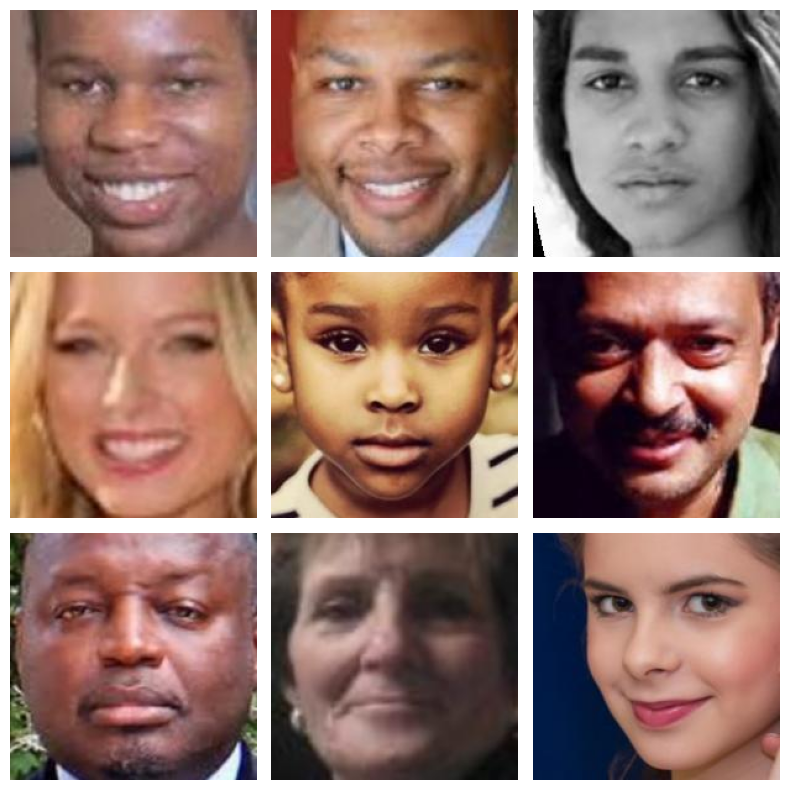

In [33]:
sample_files = random.sample(list(df['filename']), 9)

fig, axes = plt.subplots(3,3, figsize=(8,8))

for ax, file in zip(axes.flatten(), sample_files):
    img = Image.open(os.path.join(dataset_path, file))
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()

plt.savefig(
    f"{FIGURES_DIR}/sample_faces.pdf",
    bbox_inches='tight'
)

plt.show()

### Verify Project Outputs

In [34]:
folders = [
    FIGURES_DIR,
    DATA_DIR,
    MODELS_DIR,
    RESULTS_DIR,
    LOGS_DIR
]

for folder in folders:
    print(f"\n{folder}")
    print(os.listdir(folder))


/kaggle/working/project_figures
['class_distribution.pdf', 'sample_faces.pdf', 'age_distribution.pdf']

/kaggle/working/project_data
['test_df.csv', 'dataset_statistics.csv', 'val_df.csv', 'train_df.csv', 'metadata.csv']

/kaggle/working/saved_models
[]

/kaggle/working/evaluation_results
[]

/kaggle/working/logs
[]


# Step 12: Build the Baseline CNN Model

## Description

The first model should be a custom CNN built from scratch.

Why?

* Serves as a baseline.
* Provides a reference point for comparison.
* Helps demonstrate the benefit of transfer learning later.
* Required in most Pattern Recognition and Deep Learning projects.

The architecture does not need to be complex.

## Step 12.1: Import Deep Learning Libraries

In [35]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


## Step 12.2: Compute Class Weights

### Description

Your classes are imbalanced:

| Class |  Count |
| ----- | -----: |
| Adult | 11,463 |
| Young |  7,637 |
| Old   |  4,608 |

Class weights help prevent the model from favoring the Adult class.

In [36]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["class"]),
    y=train_df["class"]
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

pd.DataFrame(
    class_weights.items(),
    columns=["class_index", "weight"]
).to_csv(
    "/kaggle/working/project_data/class_weights.csv",
    index=False
)

{0: np.float64(0.6893901628447989), 1: np.float64(1.7152454780361757), 2: np.float64(1.0347300162114976)}


## Step 12.3: Build CNN Architecture

### Description

Architecture:

```text
Input (224x224x3)

Conv -> BN -> Pool

Conv -> BN -> Pool

Conv -> BN -> Pool

Flatten

Dense(256)

Dropout

Dense(3)
```

In [37]:
cnn_model = Sequential([

    Input(shape=(224,224,3)),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

I0000 00:00:1780603390.168086      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Step 12.4: Compile Model

### Description

Since this is a multi-class classification problem:

* Loss = Categorical Crossentropy
* Optimizer = Adam
* Metric = Accuracy

In [38]:
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Step 12.5: Display Model Summary

In [39]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,397,315 (73.99 MB)

 Trainable params: 19,396,355 (73.99 MB)

 Non-trainable params: 960 (3.75 KB)

## Step 12.6: Save Architecture Summary

In [40]:
with open(
    "/kaggle/working/project_data/cnn_architecture.txt",
    "w"
) as f:

    cnn_model.summary(
        print_fn=lambda x: f.write(x + "\n")
    )

# Step 13: Train the Baseline CNN

Before training, we'll create professional callbacks:

### Early Stopping

In [41]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)

### Callbacks

In [42]:
cnn_callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        verbose=1
    ),

    ModelCheckpoint(
        filepath='/kaggle/working/saved_models/cnn_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(
        '/kaggle/working/logs/cnn_training_log.csv'
    )
]

### Then train

In [43]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=cnn_callbacks
)

Epoch 1/20


I0000 00:00:1780603396.252191     164 service.cc:152] XLA service 0x7d41a8017c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780603396.252244     164 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780603396.957382     164 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/519 ━━━━━━━━━━━━━━━━━━━━ 1:36:19 11s/step - accuracy: 0.2188 - loss: 3.5269

I0000 00:00:1780603403.552333     164 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.4003 - loss: 1.6948
Epoch 1: val_accuracy improved from None to 0.54078, saving model to /kaggle/working/saved_models/cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/saved_models/cnn_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 191s 347ms/step - accuracy: 0.4134 - loss: 1.3290 - val_accuracy: 0.5408 - val_loss: 0.9782 - learning_rate: 1.0000e-04
Epoch 2/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.4603 - loss: 1.0478
Epoch 2: val_accuracy improved from 0.54078 to 0.56665, saving model to /kaggle/working/saved_models/cnn_best.keras

Epoch 2: finished saving model to /kaggle/working/saved_models/cnn_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 173s 333ms/step - accuracy: 0.4671 - loss: 1.0290 - val_accuracy: 0.5666 - val_loss: 0.9374 - learning_rate: 1.0000e-04
Epoch 3/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.4937 - loss: 0.9942
Epoch 3: val_accuracy did not improve from 0.56665
519/519 ━━━

# 17. Accuracy and Loss Curves

Training and validation accuracy/loss curves are plotted to evaluate model learning behavior during training. These curves help identify overfitting, underfitting, and convergence performance.

## 17.1 Plot Accuracy Curve

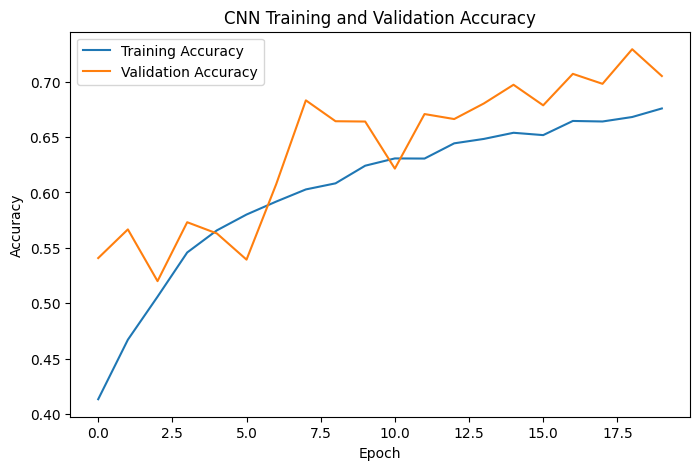

In [44]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig(f"{PROJECT_FIGURES}/cnn-training-and-validation_accuracy.pdf", bbox_inches="tight")
plt.show()

## 17.2 Plot Loss Curve

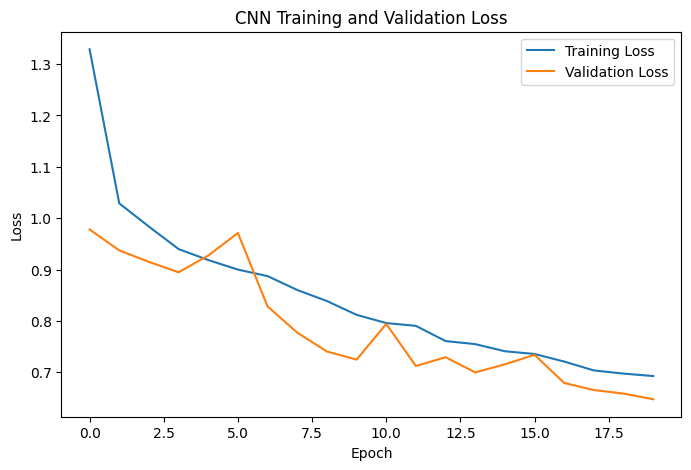

In [45]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(f"{PROJECT_FIGURES}/cnn-training-and-validation_loss.pdf", bbox_inches="tight")
plt.show()

## 17.3 Evaluate CNN on Validation Set

In [71]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Evaluation libraries ready.")

Evaluation libraries ready.


### Class Index Mapping

In [72]:
# Recover class index mapping from the validation generator
class_indices = val_generator.class_indices      # e.g. {'adult':0, 'old':1, 'young':2}
idx_to_class  = {v: k for k, v in class_indices.items()}
class_names   = [idx_to_class[i] for i in range(len(class_indices))]

print("Class index mapping:", class_indices)
print("Class names order  :", class_names)

Class index mapping: {'adult': 0, 'old': 1, 'young': 2}
Class names order  : ['adult', 'old', 'young']


### Inference Time Measurement

In [73]:
# Warm-up pass (excludes JIT / graph compilation overhead)
_ = cnn_model.predict(val_generator, verbose=0)

# Timed pass
start_inf = time.time()
val_preds_prob_cnn = cnn_model.predict(val_generator, verbose=1)
inf_time_cnn = time.time() - start_inf

total_samples    = len(val_generator.filenames)
per_image_ms_cnn = (inf_time_cnn / total_samples) * 1000

print(f"\nTotal inference time : {inf_time_cnn:.2f} s  ({total_samples} images)")
print(f"Per-image latency    : {per_image_ms_cnn:.2f} ms")

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step

Total inference time : 3.92 s  (3556 images)
Per-image latency    : 1.10 ms


### Classification Report

In [74]:
val_preds_class_cnn = np.argmax(val_preds_prob_cnn, axis=1)
val_true_class_cnn  = val_generator.classes

report_cnn = classification_report(
    val_true_class_cnn,
    val_preds_class_cnn,
    target_names=class_names,
    output_dict=True
)

report_cnn_df = pd.DataFrame(report_cnn).transpose()
print("Classification Report — CNN (Validation Set)")
print(report_cnn_df.round(4).to_string())

report_cnn_df.to_csv(
    f"{EVALUATION_RESULTS}/cnn_classification_report.csv"
)
print("\nReport saved.")

Classification Report — CNN (Validation Set)
              precision  recall  f1-score    support
adult            0.4784  0.3997    0.4355  1719.0000
old              0.1888  0.2486    0.2146   692.0000
young            0.3408  0.3598    0.3500  1145.0000
accuracy         0.3574  0.3574    0.3574     0.3574
macro avg        0.3360  0.3360    0.3334  3556.0000
weighted avg     0.3777  0.3574    0.3650  3556.0000

Report saved.


### Confusion Matrix

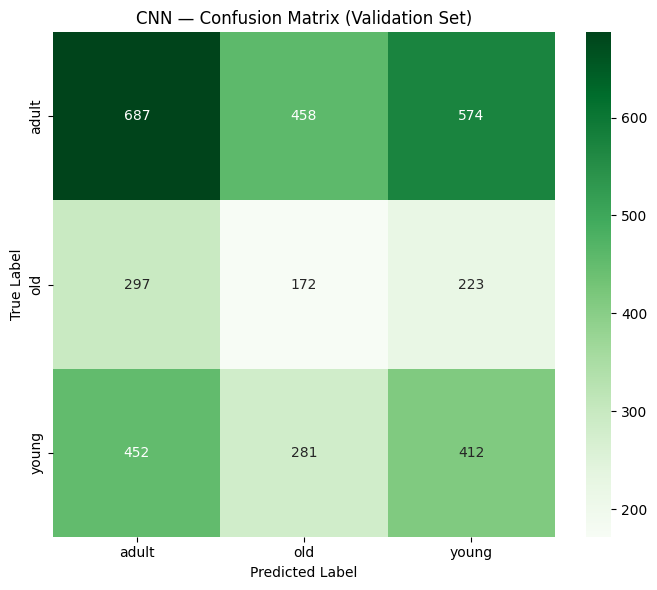

Confusion matrix saved.


In [75]:
cm_cnn = confusion_matrix(val_true_class_cnn, val_preds_class_cnn)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("CNN — Confusion Matrix (Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig(
    f"{PROJECT_FIGURES}/cnn_confusion_matrix.pdf",
    bbox_inches="tight"
)
plt.show()

np.save(
    f"{EVALUATION_RESULTS}/cnn_confusion_matrix.npy",
    cm_cnn
)
print("Confusion matrix saved.")

### ROC-AUC Score (One-vs-Rest)

In [76]:
val_true_onehot_cnn = tf.keras.utils.to_categorical(
    val_true_class_cnn, num_classes=len(class_names)
)

roc_auc_per_class_cnn = roc_auc_score(
    val_true_onehot_cnn,
    val_preds_prob_cnn,
    average=None
)

roc_auc_macro_cnn = roc_auc_score(
    val_true_onehot_cnn,
    val_preds_prob_cnn,
    average='macro'
)

print("ROC-AUC per class:")
for cls, auc in zip(class_names, roc_auc_per_class_cnn):
    print(f"  {cls:<8}: {auc:.4f}")
print(f"\nMacro ROC-AUC: {roc_auc_macro_cnn:.4f}")

roc_cnn_df = pd.DataFrame({
    'class'  : class_names + ['macro'],
    'roc_auc': list(roc_auc_per_class_cnn) + [roc_auc_macro_cnn]
})
roc_cnn_df.to_csv(
    f"{EVALUATION_RESULTS}/cnn_roc_auc.csv",
    index=False
)
print("ROC-AUC scores saved.")

ROC-AUC per class:
  adult   : 0.4910
  old     : 0.5017
  young   : 0.5127

Macro ROC-AUC: 0.5018
ROC-AUC scores saved.


### Save Summary Metrics for Benchmarking

In [77]:
val_loss_cnn, val_acc_cnn = cnn_model.evaluate(val_generator, verbose=1)

summary_metrics_cnn = {
    'model'            : 'CNN',
    'val_accuracy'     : round(val_acc_cnn, 4),
    'val_loss'         : round(val_loss_cnn, 4),
    'macro_precision'  : round(report_cnn['macro avg']['precision'], 4),
    'macro_recall'     : round(report_cnn['macro avg']['recall'],    4),
    'macro_f1'         : round(report_cnn['macro avg']['f1-score'],  4),
    'macro_roc_auc'    : round(roc_auc_macro_cnn, 4),
    'inference_time_s' : round(inf_time_cnn, 2),
    'per_image_ms'     : round(per_image_ms_cnn, 2),
}

pd.DataFrame([summary_metrics_cnn]).to_csv(
    f"{EVALUATION_RESULTS}/cnn_summary_metrics.csv",
    index=False
)

print("CNN Summary Metrics:")
for k, v in summary_metrics_cnn.items():
    print(f"  {k:<22}: {v}")
print(f"\nSaved to evaluation_results/cnn_summary_metrics.csv")

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7050 - loss: 0.6477
CNN Summary Metrics:
  model                 : CNN
  val_accuracy          : 0.705
  val_loss              : 0.6477
  macro_precision       : 0.336
  macro_recall          : 0.336
  macro_f1              : 0.3334
  macro_roc_auc         : 0.5018
  inference_time_s      : 3.92
  per_image_ms          : 1.1

Saved to evaluation_results/cnn_summary_metrics.csv


### Save Final CNN Model

In [78]:
cnn_final_path = f"{SAVED_MODELS}/cnn_final.keras"
cnn_model.save(cnn_final_path)
print(f"CNN final model saved to: {cnn_final_path}")

print("\nSaved models directory:")
for fname in sorted(os.listdir(SAVED_MODELS)):
    size_mb = os.path.getsize(os.path.join(SAVED_MODELS, fname)) / 1e6
    print(f"  {fname:<45}  {size_mb:.1f} MB")

CNN final model saved to: /kaggle/working/saved_models/cnn_final.keras

Saved models directory:
  cnn_best.keras                                 232.8 MB
  cnn_final.keras                                232.8 MB
  mobilenetv2_best.keras                         25.9 MB
  mobilenetv2_phase1_best.keras                  13.6 MB
  resnet50_best.keras                            217.0 MB
  resnet50_final.keras                           217.0 MB
  resnet50_phase1_best.keras                     101.4 MB


# Step 14: MobileNetV2 — Transfer Learning Model

## Description

MobileNetV2 is a lightweight, efficient deep neural network architecture designed for mobile and embedded vision applications. It introduces two key innovations:

- **Inverted residuals**: Expand features in a bottleneck layer, apply depthwise convolution, then project back to a smaller dimension.
- **Linear bottlenecks**: Prevent information loss when projecting back to a lower dimension by removing the non-linearity at the output of each bottleneck.

### Why MobileNetV2 for this task?

| Property | Value |
| --- | --- |
| Pre-trained on | ImageNet (1.2M images, 1000 classes) |
| Input size | 224 × 224 × 3 |
| Parameters | ~3.4 M (frozen base) |
| Strengths | Fast inference, small memory footprint, good accuracy |

### Transfer Learning Strategy

The base MobileNetV2 is loaded with **ImageNet weights** and initially **frozen**. A custom classification head is added on top. Training is done in two phases:

1. **Phase 1 — Feature Extraction**: Only the custom head is trained (base frozen).
2. **Phase 2 — Fine-Tuning**: The top layers of the base are unfrozen and trained with a very low learning rate.

This approach leverages pre-trained feature representations while adapting the model to our 3-class age-group problem.

## Step 14.1: Import Libraries for MobileNetV2

In [46]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import seaborn as sns

print("TensorFlow Version:", tf.__version__)
print("All MobileNetV2 libraries imported successfully.")

TensorFlow Version: 2.19.0
All MobileNetV2 libraries imported successfully.


## Step 14.2: Build MobileNetV2 Architecture

### Phase 1 — Feature Extraction

The base MobileNetV2 is loaded with ImageNet weights and frozen. A classification head consisting of Global Average Pooling, Batch Normalization, Dense(256), Dropout, and a final Dense(3, softmax) layer is appended.

In [47]:
# Load MobileNetV2 base (frozen)
mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,         # Remove original classifier
    input_shape=(224, 224, 3)
)
mobilenet_base.trainable = False  # Freeze all base layers

# Build classification head
inputs = Input(shape=(224, 224, 3), name='input_layer')
x = mobilenet_base(inputs, training=False)
x = GlobalAveragePooling2D(name='global_avg_pool')(x)
x = BatchNormalization(name='bn_head')(x)
x = Dense(256, activation='relu', name='dense_256')(x)
x = Dropout(0.4, name='dropout_04')(x)
outputs = Dense(3, activation='softmax', name='output_softmax')(x)

mobilenet_model = Model(inputs, outputs, name='MobileNetV2_AgeGroup')

print("MobileNetV2 model built successfully.")
print(f"Base layers frozen: {len(mobilenet_base.layers)}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 model built successfully.
Base layers frozen: 154


## Step 14.3: Display Model Summary

In [48]:
mobilenet_model.summary()

Model: "MobileNetV2_AgeGroup"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_04 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,811 (9.89 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

### Save Architecture Summary to File

In [49]:
arch_path = f"{PROJECT_DATA}/mobilenetv2_architecture.txt"

with open(arch_path, "w") as f:
    mobilenet_model.summary(print_fn=lambda x: f.write(x + "\n"))

print(f"Architecture summary saved to: {arch_path}")

Architecture summary saved to: /kaggle/working/project_data/mobilenetv2_architecture.txt


## Step 14.4: Compile and Train — Phase 1 (Feature Extraction)

The model is compiled with a relatively high learning rate for the head layers. Early stopping and learning rate reduction are applied.

In [50]:
import time

# Compile — Phase 1
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks — Phase 1
mobilenet_callbacks_p1 = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=f'{SAVED_MODELS}/mobilenetv2_phase1_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(f'{LOGS_DIR}/mobilenetv2_phase1_log.csv')
]

print("Phase 1 — Feature Extraction Training")
print(f"Trainable parameters: {mobilenet_model.count_params():,}")

start_time_p1 = time.time()

history_mobilenet_p1 = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=mobilenet_callbacks_p1
)

p1_time = time.time() - start_time_p1
print(f"\nPhase 1 training completed in {p1_time:.1f} seconds.")

Phase 1 — Feature Extraction Training
Trainable parameters: 2,591,811
Epoch 1/15
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.5660 - loss: 1.0741
Epoch 1: val_accuracy improved from None to 0.64454, saving model to /kaggle/working/saved_models/mobilenetv2_phase1_best.keras

Epoch 1: finished saving model to /kaggle/working/saved_models/mobilenetv2_phase1_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 226s 410ms/step - accuracy: 0.6015 - loss: 0.9114 - val_accuracy: 0.6445 - val_loss: 0.7488 - learning_rate: 0.0010
Epoch 2/15
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.6503 - loss: 0.7260
Epoch 2: val_accuracy improved from 0.64454 to 0.68560, saving model to /kaggle/working/saved_models/mobilenetv2_phase1_best.keras

Epoch 2: finished saving model to /kaggle/working/saved_models/mobilenetv2_phase1_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 196s 377ms/step - accuracy: 0.6518 - loss: 0.7159 - val_accuracy: 0.6856 - val_loss: 0.6783 - learning_rate: 0.0010
Epoch 3/15
519/51

## Step 14.5: Fine-Tuning — Unfreeze Top Layers (Phase 2)

After the head has converged, the top 30 layers of the MobileNetV2 base are unfrozen and retrained with a very low learning rate to adapt higher-level features to the age-group task.

In [51]:
# Unfreeze the top 30 layers of the base
mobilenet_base.trainable = True

fine_tune_from = len(mobilenet_base.layers) - 30

for layer in mobilenet_base.layers[:fine_tune_from]:
    layer.trainable = False

print(f"Total base layers        : {len(mobilenet_base.layers)}")
print(f"Fine-tuning from layer   : {fine_tune_from}")
print(f"Trainable layers unfrozen: {len(mobilenet_base.layers) - fine_tune_from}")

# Recompile with a very low learning rate
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks — Phase 2
mobilenet_callbacks_p2 = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=f'{SAVED_MODELS}/mobilenetv2_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(f'{LOGS_DIR}/mobilenetv2_phase2_log.csv')
]

print("\nPhase 2 — Fine-Tuning Training")

start_time_p2 = time.time()

history_mobilenet_p2 = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=mobilenet_callbacks_p2
)

p2_time = time.time() - start_time_p2
print(f"\nPhase 2 training completed in {p2_time:.1f} seconds.")

Total base layers        : 154
Fine-tuning from layer   : 124
Trainable layers unfrozen: 30

Phase 2 — Fine-Tuning Training
Epoch 1/20


2026-06-04 21:57:07.415891: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 21:57:07.613408: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


276/519 ━━━━━━━━━━━━━━━━━━━━ 1:27 359ms/step - accuracy: 0.6304 - loss: 0.7487

2026-06-04 21:58:54.860237: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 21:58:55.062331: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 21:58:55.261586: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 21:58:55.463367: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.6384 - loss: 0.7303
Epoch 1: val_accuracy improved from None to 0.68729, saving model to /kaggle/working/saved_models/mobilenetv2_best.keras

Epoch 1: finished saving model to /kaggle/working/saved_models/mobilenetv2_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 226s 400ms/step - accuracy: 0.6560 - loss: 0.6953 - val_accuracy: 0.6873 - val_loss: 0.7078 - learning_rate: 1.0000e-05
Epoch 2/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.6731 - loss: 0.6570
Epoch 2: val_accuracy improved from 0.68729 to 0.72216, saving model to /kaggle/working/saved_models/mobilenetv2_best.keras

Epoch 2: finished saving model to /kaggle/working/saved_models/mobilenetv2_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 192s 369ms/step - accuracy: 0.6804 - loss: 0.6470 - val_accuracy: 0.7222 - val_loss: 0.6195 - learning_rate: 1.0000e-05
Epoch 3/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.6874 - loss: 0.6293
Epoch 3: val_accuracy did not 

## Step 14.6: Merge Phase 1 and Phase 2 Training Histories

In [52]:
def merge_histories(h1, h2):
    """Concatenate two Keras history objects for combined plotting."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

history_mobilenet = merge_histories(history_mobilenet_p1, history_mobilenet_p2)

print("Merged history keys:", list(history_mobilenet.keys()))
print(f"Total epochs trained : {len(history_mobilenet['accuracy'])}")

Merged history keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']
Total epochs trained : 32


## Step 14.7: Plot Training and Validation Accuracy

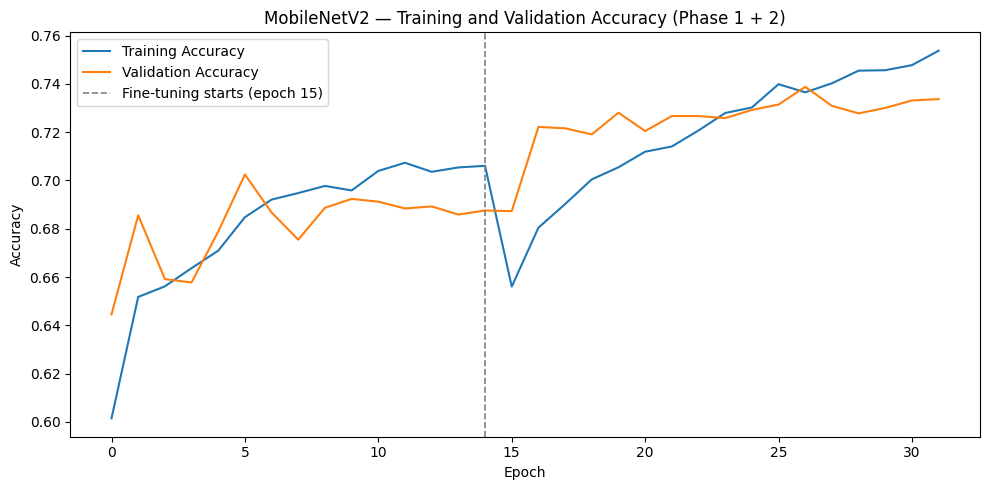

Accuracy plot saved.


In [53]:
p1_epochs = len(history_mobilenet_p1.history['accuracy'])
total_epochs = len(history_mobilenet['accuracy'])

plt.figure(figsize=(10, 5))

plt.plot(history_mobilenet['accuracy'], label='Training Accuracy')
plt.plot(history_mobilenet['val_accuracy'], label='Validation Accuracy')

# Mark the boundary between Phase 1 and Phase 2
plt.axvline(
    x=p1_epochs - 1,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    label=f'Fine-tuning starts (epoch {p1_epochs})'
)

plt.title("MobileNetV2 — Training and Validation Accuracy (Phase 1 + 2)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{PROJECT_FIGURES}/mobilenetv2_accuracy.pdf",
    bbox_inches="tight"
)
plt.show()
print("Accuracy plot saved.")

## Step 14.8: Plot Training and Validation Loss

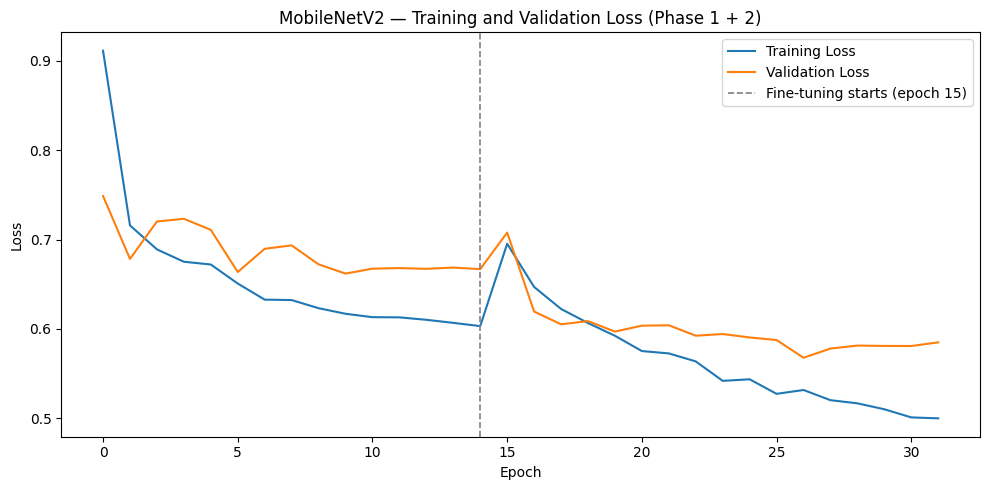

Loss plot saved.


In [54]:
plt.figure(figsize=(10, 5))

plt.plot(history_mobilenet['loss'], label='Training Loss')
plt.plot(history_mobilenet['val_loss'], label='Validation Loss')

plt.axvline(
    x=p1_epochs - 1,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    label=f'Fine-tuning starts (epoch {p1_epochs})'
)

plt.title("MobileNetV2 — Training and Validation Loss (Phase 1 + 2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{PROJECT_FIGURES}/mobilenetv2_loss.pdf",
    bbox_inches="tight"
)
plt.show()
print("Loss plot saved.")

## Step 14.9: Evaluate MobileNetV2 on Validation Set

The test set is preserved strictly for the final benchmarking step after all models are trained. Evaluation here uses the **validation set** only.

In [55]:
# Class index mapping from generator
class_indices = val_generator.class_indices          # e.g. {'adult':0,'old':1,'young':2}
idx_to_class  = {v: k for k, v in class_indices.items()}
class_names   = [idx_to_class[i] for i in range(3)]

print("Class index mapping:", class_indices)
print("Class names order  :", class_names)

Class index mapping: {'adult': 0, 'old': 1, 'young': 2}
Class names order  : ['adult', 'old', 'young']


### Inference Time Measurement

In [66]:
# Warm-up pass
_ = mobilenet_model.predict(val_generator, verbose=0)

# Timed pass
start_inf = time.time()
val_preds_prob = mobilenet_model.predict(val_generator, verbose=1)
inf_time = time.time() - start_inf

total_samples = len(val_generator.filenames)
per_image_ms  = (inf_time / total_samples) * 1000

print(f"\nTotal inference time : {inf_time:.2f} s  ({total_samples} images)")
print(f"Per-image latency    : {per_image_ms:.2f} ms")

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step

Total inference time : 3.96 s  (3556 images)
Per-image latency    : 1.11 ms


### Classification Report

In [67]:
val_preds_class = np.argmax(val_preds_prob, axis=1)
val_true_class  = val_generator.classes

report = classification_report(
    val_true_class,
    val_preds_class,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
print("Classification Report — MobileNetV2 (Validation Set)")
print(report_df.round(4).to_string())

report_df.to_csv(
    f"{EVALUATION_RESULTS}/mobilenetv2_classification_report.csv"
)
print(f"\nReport saved.")

Classification Report — MobileNetV2 (Validation Set)
              precision  recall  f1-score    support
adult            0.4817  0.4602    0.4707  1719.0000
old              0.1808  0.1936    0.1870   692.0000
young            0.3112  0.3188    0.3149  1145.0000
accuracy         0.3628  0.3628    0.3628     0.3628
macro avg        0.3246  0.3242    0.3242  3556.0000
weighted avg     0.3683  0.3628    0.3653  3556.0000

Report saved.


### Confusion Matrix

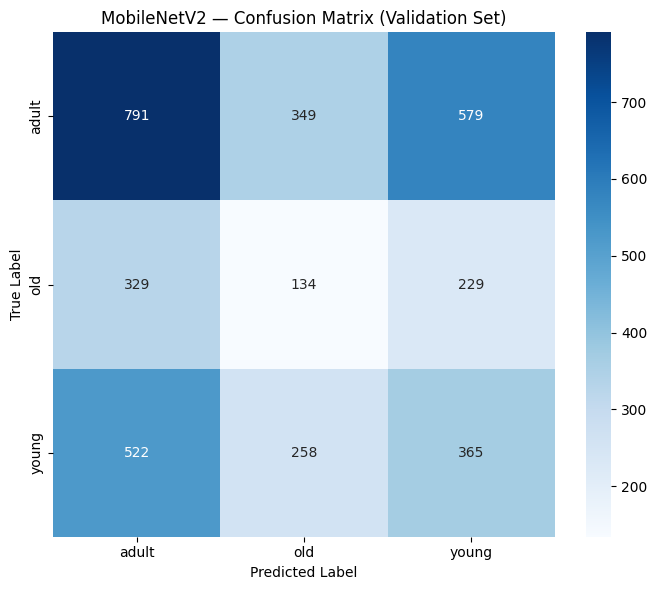

Confusion matrix saved.


In [68]:
cm = confusion_matrix(val_true_class, val_preds_class)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("MobileNetV2 — Confusion Matrix (Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig(
    f"{PROJECT_FIGURES}/mobilenetv2_confusion_matrix.pdf",
    bbox_inches="tight"
)
plt.show()

np.save(
    f"{EVALUATION_RESULTS}/mobilenetv2_confusion_matrix.npy",
    cm
)
print("Confusion matrix saved.")

### ROC-AUC Score (One-vs-Rest)

In [69]:
val_true_onehot = tf.keras.utils.to_categorical(val_true_class, num_classes=3)

roc_auc_per_class = roc_auc_score(
    val_true_onehot,
    val_preds_prob,
    average=None
)

roc_auc_macro = roc_auc_score(
    val_true_onehot,
    val_preds_prob,
    average='macro'
)

print("ROC-AUC per class:")
for cls, auc in zip(class_names, roc_auc_per_class):
    print(f"  {cls:<8}: {auc:.4f}")
print(f"\nMacro ROC-AUC: {roc_auc_macro:.4f}")

roc_df = pd.DataFrame({
    'class': class_names + ['macro'],
    'roc_auc': list(roc_auc_per_class) + [roc_auc_macro]
})
roc_df.to_csv(
    f"{EVALUATION_RESULTS}/mobilenetv2_roc_auc.csv",
    index=False
)
print("ROC-AUC scores saved.")

ROC-AUC per class:
  adult   : 0.4996
  old     : 0.4963
  young   : 0.4790

Macro ROC-AUC: 0.4916
ROC-AUC scores saved.


## Step 14.10: Save Summary Metrics for Benchmarking

In [70]:
val_loss, val_acc = mobilenet_model.evaluate(val_generator, verbose=1)

summary_metrics = {
    'model'               : 'MobileNetV2',
    'val_accuracy'        : round(val_acc, 4),
    'val_loss'            : round(val_loss, 4),
    'macro_precision'     : round(report['macro avg']['precision'], 4),
    'macro_recall'        : round(report['macro avg']['recall'],    4),
    'macro_f1'            : round(report['macro avg']['f1-score'],  4),
    'macro_roc_auc'       : round(roc_auc_macro, 4),
    'inference_time_s'    : round(inf_time, 2),
    'per_image_ms'        : round(per_image_ms, 2),
    'phase1_epochs'       : p1_epochs,
    'total_epochs'        : total_epochs,
    'phase1_train_time_s' : round(p1_time, 1),
    'phase2_train_time_s' : round(p2_time, 1),
}

summary_df = pd.DataFrame([summary_metrics])
summary_df.to_csv(
    f"{EVALUATION_RESULTS}/mobilenetv2_summary_metrics.csv",
    index=False
)

print("MobileNetV2 Summary Metrics:")
for k, v in summary_metrics.items():
    print(f"  {k:<28}: {v}")
print(f"\nSummary saved to evaluation_results/mobilenetv2_summary_metrics.csv")

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.7388 - loss: 0.5677
MobileNetV2 Summary Metrics:
  model                       : MobileNetV2
  val_accuracy                : 0.7388
  val_loss                    : 0.5677
  macro_precision             : 0.3246
  macro_recall                : 0.3242
  macro_f1                    : 0.3242
  macro_roc_auc               : 0.4916
  inference_time_s            : 3.96
  per_image_ms                : 1.11
  phase1_epochs               : 13
  total_epochs                : 33
  phase1_train_time_s         : 2560.8
  phase2_train_time_s         : 3977.1

Summary saved to evaluation_results/mobilenetv2_summary_metrics.csv


# Step 15: ResNet50 — Transfer Learning Model

## Description

ResNet50 is a deep residual network with 50 layers, introduced by He et al. (2015). Its defining innovation is the **residual (skip) connection**, which adds the input of a block directly to its output. This allows gradients to flow unchanged through the network, enabling successful training of very deep architectures without vanishing-gradient degradation.

### Why ResNet50 for this task?

| Property | Value |
| --- | --- |
| Pre-trained on | ImageNet (1.2M images, 1000 classes) |
| Input size | 224 × 224 × 3 |
| Parameters | ~25.6 M (frozen base) |
| Strengths | Strong feature extraction, well-studied, robust to depth |

### Transfer Learning Strategy

The base ResNet50 is loaded with **ImageNet weights** and initially **frozen**. A custom classification head is added on top. Training is done in two phases:

1. **Phase 1 — Feature Extraction**: Only the custom head is trained (base frozen).
2. **Phase 2 — Fine-Tuning**: The top layers of the base are unfrozen and trained with a very low learning rate.

This mirrors the strategy used for MobileNetV2, ensuring a fair comparison between the two transfer learning models.

## Step 15.1: Import Libraries for ResNet50

In [56]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import seaborn as sns
import time

print("TensorFlow Version:", tf.__version__)
print("All ResNet50 libraries imported successfully.")

TensorFlow Version: 2.19.0
All ResNet50 libraries imported successfully.


## Step 15.2: Build ResNet50 Architecture

### Phase 1 — Feature Extraction

The base ResNet50 is loaded with ImageNet weights and frozen. A classification head consisting of Global Average Pooling, Batch Normalization, Dense(256), Dropout, and a final Dense(3, softmax) layer is appended.

In [57]:
# Load ResNet50 base (frozen)
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,          # Remove original classifier
    input_shape=(224, 224, 3)
)
resnet_base.trainable = False   # Freeze all base layers

# Build classification head
inputs = Input(shape=(224, 224, 3), name='input_layer')
x = resnet_base(inputs, training=False)
x = GlobalAveragePooling2D(name='global_avg_pool')(x)
x = BatchNormalization(name='bn_head')(x)
x = Dense(256, activation='relu', name='dense_256')(x)
x = Dropout(0.4, name='dropout_04')(x)
outputs = Dense(3, activation='softmax', name='output_softmax')(x)

resnet_model = Model(inputs, outputs, name='ResNet50_AgeGroup')

print("ResNet50 model built successfully.")
print(f"Base layers frozen: {len(resnet_base.layers)}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 model built successfully.
Base layers frozen: 175


## Step 15.3: Display Model Summary

In [58]:
resnet_model.summary()

Model: "ResNet50_AgeGroup"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 2048)           │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_04 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,219 (92.02 MB)

 Trainable params: 529,411 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## Step 15.4: Compile and Train — Phase 1 (Feature Extraction)

The model is compiled with a relatively high learning rate for the head layers. Early stopping and learning rate reduction are applied.

In [59]:
# Compile — Phase 1
resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks — Phase 1
resnet_callbacks_p1 = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=f'{SAVED_MODELS}/resnet50_phase1_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(f'{LOGS_DIR}/resnet50_phase1_log.csv')
]

print("Phase 1 — Feature Extraction Training")
print(f"Trainable parameters: {resnet_model.count_params():,}")

start_time_p1 = time.time()

history_resnet_p1 = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=resnet_callbacks_p1
)

p1_time = time.time() - start_time_p1
print(f"\nPhase 1 training completed in {p1_time:.1f} seconds.")

Phase 1 — Feature Extraction Training
Trainable parameters: 24,121,219
Epoch 1/15
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.4617 - loss: 1.0605
Epoch 1: val_accuracy improved from None to 0.54528, saving model to /kaggle/working/saved_models/resnet50_phase1_best.keras

Epoch 1: finished saving model to /kaggle/working/saved_models/resnet50_phase1_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 222s 402ms/step - accuracy: 0.4821 - loss: 1.0231 - val_accuracy: 0.5453 - val_loss: 0.9835 - learning_rate: 0.0010
Epoch 2/15
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.5116 - loss: 0.9679
Epoch 2: val_accuracy improved from 0.54528 to 0.59280, saving model to /kaggle/working/saved_models/resnet50_phase1_best.keras

Epoch 2: finished saving model to /kaggle/working/saved_models/resnet50_phase1_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 195s 375ms/step - accuracy: 0.5089 - loss: 0.9630 - val_accuracy: 0.5928 - val_loss: 0.8772 - learning_rate: 0.0010
Epoch 3/15
519/519 ━━━━━━━━━

## Step 15.5: Fine-Tuning — Unfreeze Top Layers (Phase 2)

After the head has converged, the top 30 layers of the ResNet50 base are unfrozen and retrained with a very low learning rate to adapt higher-level features to the age-group task.

In [60]:
# Unfreeze the top 30 layers of the base
resnet_base.trainable = True

fine_tune_from = len(resnet_base.layers) - 30

for layer in resnet_base.layers[:fine_tune_from]:
    layer.trainable = False

print(f"Total base layers        : {len(resnet_base.layers)}")
print(f"Fine-tuning from layer   : {fine_tune_from}")
print(f"Trainable layers unfrozen: {len(resnet_base.layers) - fine_tune_from}")

# Recompile with a very low learning rate
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks — Phase 2
resnet_callbacks_p2 = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=f'{SAVED_MODELS}/resnet50_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(f'{LOGS_DIR}/resnet50_phase2_log.csv')
]

print("\nPhase 2 — Fine-Tuning Training")

start_time_p2 = time.time()

history_resnet_p2 = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=resnet_callbacks_p2
)

p2_time = time.time() - start_time_p2
print(f"\nPhase 2 training completed in {p2_time:.1f} seconds.")

Total base layers        : 175
Fine-tuning from layer   : 145
Trainable layers unfrozen: 30

Phase 2 — Fine-Tuning Training
Epoch 1/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.4279 - loss: 1.5987
Epoch 1: val_accuracy improved from None to 0.38048, saving model to /kaggle/working/saved_models/resnet50_best.keras

Epoch 1: finished saving model to /kaggle/working/saved_models/resnet50_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 237s 416ms/step - accuracy: 0.4578 - loss: 1.3632 - val_accuracy: 0.3805 - val_loss: 1.4336 - learning_rate: 1.0000e-05
Epoch 2/20
519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.5063 - loss: 1.0859
Epoch 2: val_accuracy improved from 0.38048 to 0.39904, saving model to /kaggle/working/saved_models/resnet50_best.keras

Epoch 2: finished saving model to /kaggle/working/saved_models/resnet50_best.keras
519/519 ━━━━━━━━━━━━━━━━━━━━ 200s 386ms/step - accuracy: 0.5100 - loss: 1.0796 - val_accuracy: 0.3990 - val_loss: 1.3701 - learning_rate: 1.0000

## Step 15.6: Merge Phase 1 and Phase 2 Training Histories

In [61]:
def merge_histories(h1, h2):
    """Concatenate two Keras history objects for combined plotting."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

history_resnet = merge_histories(history_resnet_p1, history_resnet_p2)

print("Merged history keys:", list(history_resnet.keys()))
print(f"Total epochs trained : {len(history_resnet['accuracy'])}")

Merged history keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']
Total epochs trained : 33


## Step 15.7: Plot Training and Validation Accuracy

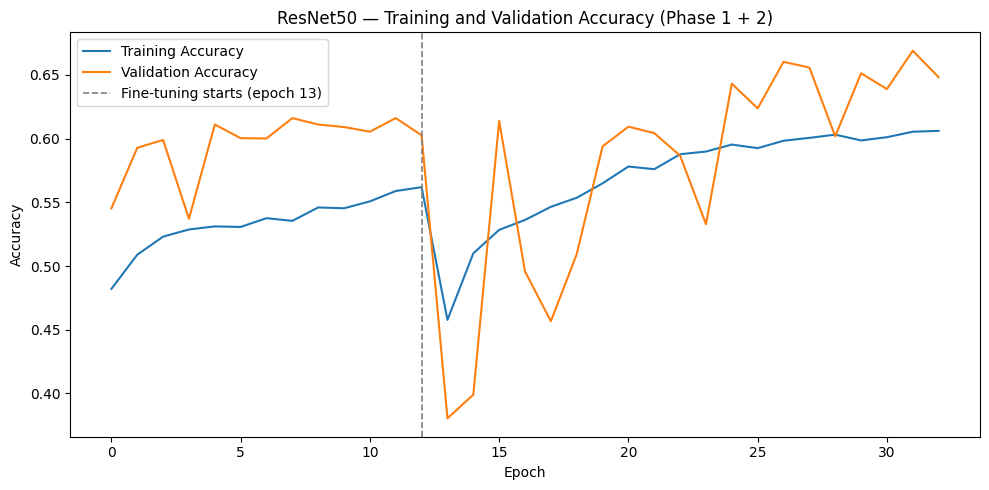

Accuracy plot saved.


In [62]:
p1_epochs = len(history_resnet_p1.history['accuracy'])
total_epochs = len(history_resnet['accuracy'])

plt.figure(figsize=(10, 5))

plt.plot(history_resnet['accuracy'], label='Training Accuracy')
plt.plot(history_resnet['val_accuracy'], label='Validation Accuracy')

# Mark the boundary between Phase 1 and Phase 2
plt.axvline(
    x=p1_epochs - 1,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    label=f'Fine-tuning starts (epoch {p1_epochs})'
)

plt.title("ResNet50 — Training and Validation Accuracy (Phase 1 + 2)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{PROJECT_FIGURES}/resnet50_accuracy.pdf",
    bbox_inches="tight"
)
plt.show()
print("Accuracy plot saved.")

## Step 15.8: Plot Training and Validation Loss

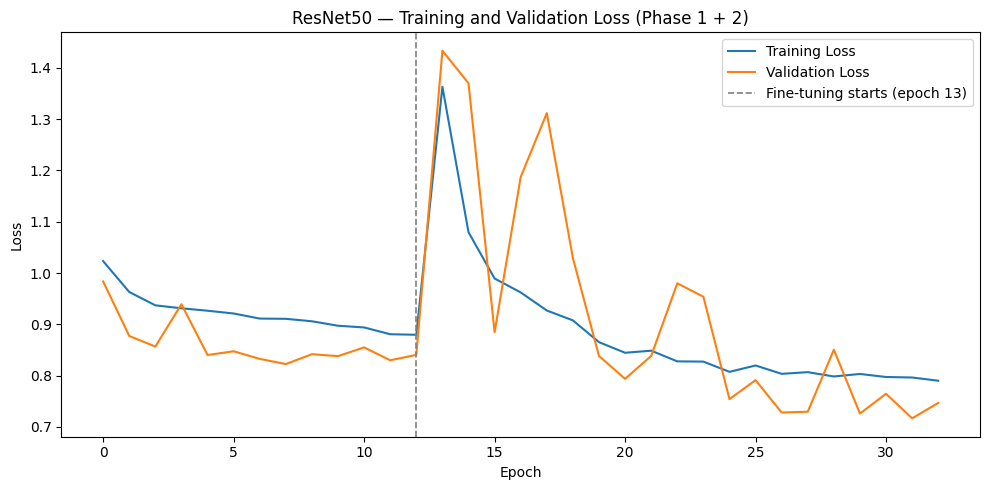

Loss plot saved.


In [63]:
plt.figure(figsize=(10, 5))

plt.plot(history_resnet['loss'], label='Training Loss')
plt.plot(history_resnet['val_loss'], label='Validation Loss')

plt.axvline(
    x=p1_epochs - 1,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    label=f'Fine-tuning starts (epoch {p1_epochs})'
)

plt.title("ResNet50 — Training and Validation Loss (Phase 1 + 2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{PROJECT_FIGURES}/resnet50_loss.pdf",
    bbox_inches="tight"
)
plt.show()
print("Loss plot saved.")

## Step 15.9: Evaluate ResNet50 on Validation Set

The test set is preserved strictly for the final benchmarking step after all models are trained. Evaluation here uses the **validation set** only.

In [64]:
# Class index mapping from generator
class_indices = val_generator.class_indices          # e.g. {'adult':0,'old':1,'young':2}
idx_to_class  = {v: k for k, v in class_indices.items()}
class_names   = [idx_to_class[i] for i in range(3)]

print("Class index mapping:", class_indices)
print("Class names order  :", class_names)

Class index mapping: {'adult': 0, 'old': 1, 'young': 2}
Class names order  : ['adult', 'old', 'young']


112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step
Predictions shape : (3556, 3)
True labels shape : (3556,)
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.6690 - loss: 0.7166

ResNet50 Validation Loss    : 0.7166
ResNet50 Validation Accuracy: 0.6690
ResNet50 — Classification Report (Validation Set)
              precision    recall  f1-score   support

       adult     0.4949    0.4799    0.4873      1719
         old     0.1873    0.2168    0.2009       692
       young     0.3180    0.3022    0.3099      1145

    accuracy                         0.3715      3556
   macro avg     0.3334    0.3330    0.3327      3556
weighted avg     0.3781    0.3715    0.3745      3556

Classification report saved to: /kaggle/working/evaluation_results/resnet50_classification_report.txt


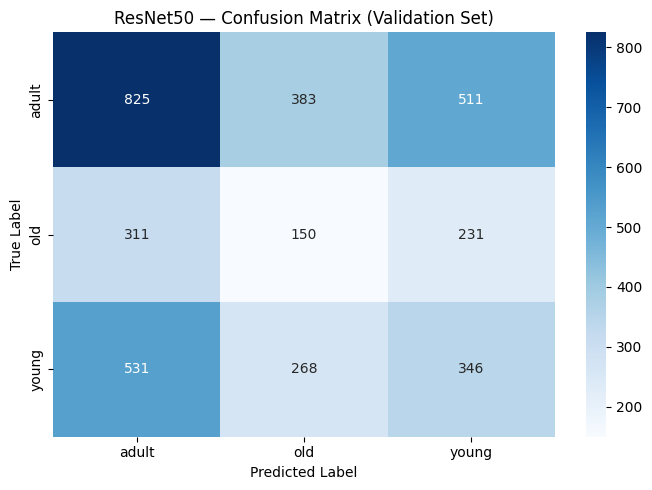

Confusion matrix saved.
ResNet50 ROC-AUC (macro, OvR): 0.4963
ResNet50 avg. inference time per image: 138.97 ms
ResNet50 evaluation metrics:
ResNet50 final model saved to: /kaggle/working/saved_models/resnet50_final.keras
Merged training history saved.

--- Saved Models ---
  resnet50_phase1_best.keras
  resnet50_best.keras
  resnet50_final.keras

--- Evaluation Results ---
  resnet50_metrics.csv
  resnet50_classification_report.txt

--- Figures ---
  resnet50_accuracy.pdf
  resnet50_confusion_matrix.pdf
  resnet50_loss.pdf

--- Logs ---
  resnet50_merged_history.csv
  resnet50_phase1_log.csv
  resnet50_phase2_log.csv


In [65]:
# Reset generator before prediction
val_generator.reset()

# Predict on validation set
resnet_val_preds = resnet_model.predict(
    val_generator,
    verbose=1
)

resnet_val_pred_classes = np.argmax(resnet_val_preds, axis=1)
resnet_val_true_classes = val_generator.classes

print("Predictions shape :", resnet_val_preds.shape)
print("True labels shape :", resnet_val_true_classes.shape)
# Validation loss and accuracy
val_loss_resnet, val_acc_resnet = resnet_model.evaluate(
    val_generator,
    verbose=1
)

print(f"\nResNet50 Validation Loss    : {val_loss_resnet:.4f}")
print(f"ResNet50 Validation Accuracy: {val_acc_resnet:.4f}")
# Classification report
resnet_report = classification_report(
    resnet_val_true_classes,
    resnet_val_pred_classes,
    target_names=class_names,
    digits=4
)

print("ResNet50 — Classification Report (Validation Set)")
print(resnet_report)

# Save classification report
report_path = f"{EVALUATION_RESULTS}/resnet50_classification_report.txt"
with open(report_path, "w") as f:
    f.write("ResNet50 — Classification Report (Validation Set)\n")
    f.write(resnet_report)

print(f"Classification report saved to: {report_path}")
# Confusion matrix
resnet_cm = confusion_matrix(
    resnet_val_true_classes,
    resnet_val_pred_classes
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    resnet_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("ResNet50 — Confusion Matrix (Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig(
    f"{PROJECT_FIGURES}/resnet50_confusion_matrix.pdf",
    bbox_inches="tight"
)
plt.show()
print("Confusion matrix saved.")
# ROC-AUC (One-vs-Rest, macro average)
from sklearn.preprocessing import label_binarize

val_true_bin = label_binarize(
    resnet_val_true_classes,
    classes=list(range(3))
)

resnet_roc_auc = roc_auc_score(
    val_true_bin,
    resnet_val_preds,
    multi_class='ovr',
    average='macro'
)

print(f"ResNet50 ROC-AUC (macro, OvR): {resnet_roc_auc:.4f}")
# Measure inference time on a single batch
sample_batch, _ = next(val_generator)

start_infer = time.time()
_ = resnet_model.predict(sample_batch, verbose=0)
infer_time_resnet = (time.time() - start_infer) / len(sample_batch)

print(f"ResNet50 avg. inference time per image: {infer_time_resnet*1000:.2f} ms")
# Save all ResNet50 metrics to CSV for benchmarking
from sklearn.metrics import precision_score, recall_score, f1_score

resnet_metrics = {
    'model'          : 'ResNet50',
    'val_loss'       : round(val_loss_resnet, 4),
    'val_accuracy'   : round(val_acc_resnet, 4),
    'precision_macro': round(precision_score(resnet_val_true_classes, resnet_val_pred_classes, average='macro'), 4),
    'recall_macro'   : round(recall_score(resnet_val_true_classes, resnet_val_pred_classes, average='macro'), 4),
    'f1_macro'       : round(f1_score(resnet_val_true_classes, resnet_val_pred_classes, average='macro'), 4),
    'roc_auc_macro'  : round(resnet_roc_auc, 4),
    'inference_ms'   : round(infer_time_resnet * 1000, 2),
    'phase1_time_s'  : round(p1_time, 1),
    'phase2_time_s'  : round(p2_time, 1),
    'total_time_s'   : round(p1_time + p2_time, 1)
}

resnet_metrics_df = pd.DataFrame([resnet_metrics])

metrics_path = f"{EVALUATION_RESULTS}/resnet50_metrics.csv"
resnet_metrics_df.to_csv(metrics_path, index=False)

print("ResNet50 evaluation metrics:")
resnet_metrics_df
# Save the final ResNet50 model
resnet_final_path = f"{SAVED_MODELS}/resnet50_final.keras"
resnet_model.save(resnet_final_path)
print(f"ResNet50 final model saved to: {resnet_final_path}")
# Save merged training history for later benchmarking
history_resnet_df = pd.DataFrame(history_resnet)
history_resnet_df.to_csv(
    f"{LOGS_DIR}/resnet50_merged_history.csv",
    index_label='epoch'
)
print("Merged training history saved.")
# Verify all ResNet50 outputs are saved
print("\n--- Saved Models ---")
for f in os.listdir(SAVED_MODELS):
    if 'resnet' in f.lower():
        print(f"  {f}")

print("\n--- Evaluation Results ---")
for f in os.listdir(EVALUATION_RESULTS):
    if 'resnet' in f.lower():
        print(f"  {f}")

print("\n--- Figures ---")
for f in os.listdir(PROJECT_FIGURES):
    if 'resnet' in f.lower():
        print(f"  {f}")

print("\n--- Logs ---")
for f in os.listdir(LOGS_DIR):
    if 'resnet' in f.lower():
        print(f"  {f}")